# Rollout Perplexity Analysis

Can the model score its own outputs? Generate N rollouts (prefix=0), compute the
model's perplexity on each rollout and the ground-truth document, then check whether
lower perplexity correlates with higher contact accuracy.

In [1]:
# Config
CHECKPOINT_PATH = "../../outputs/exp4.celestial-plant-14/"
PDB_ID = "1QYS"
CONTACT_DISTANCE_CUTOFF = 4.0
MAX_NEW_TOKENS = 3440
N_ROLLOUTS = 10
DEVICE = "cuda"

In [2]:
# Download & parse PDB structure
import tempfile
import numpy as np
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from experiments.exp4_contact_prediction.src.data import AMINO_ACIDS

# Map non-standard amino acids to their standard equivalents
NONSTANDARD_AA_MAP = {
    "MSE": "MET",  # selenomethionine -> methionine
    "CSE": "CYS",  # selenocysteine -> cysteine
    "SEC": "CYS",
    "HYP": "PRO",  # hydroxyproline -> proline
    "TPO": "THR",  # phosphothreonine -> threonine
    "SEP": "SER",  # phosphoserine -> serine
    "PTR": "TYR",  # phosphotyrosine -> tyrosine
}

path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
cif = pdbx.CIFFile.read(path)
atoms = pdbx.get_structure(cif.block, model=1)

first_chain = atoms.chain_id[0]
chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]

res_ids = chain_atoms.res_id
unique_res = sorted(set(res_ids))
res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}
sequence_raw = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]

# Map non-standard residues to standard amino acids
aa_set = set(AMINO_ACIDS)
sequence = []
for aa in sequence_raw:
    if aa in aa_set:
        sequence.append(aa)
    elif aa in NONSTANDARD_AA_MAP:
        print(f"  Mapping non-standard residue: {aa} -> {NONSTANDARD_AA_MAP[aa]}")
        sequence.append(NONSTANDARD_AA_MAP[aa])
    else:
        raise ValueError(f"Unknown amino acid: {aa} (add to NONSTANDARD_AA_MAP)")

seq_len = len(sequence)
print(f"Protein {PDB_ID}: {seq_len} residues, chain {first_chain}")

/home/ubuntu/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Mapping non-standard residue: MSE -> MET
Protein 1QYS: 92 residues, chain A


In [3]:
# Compute ground-truth contacts (one per residue pair, closest atom pair)
from scipy.spatial import KDTree
from experiments.exp4_contact_prediction.src.data import VALID_ATOMS

coords = chain_atoms.coord
atom_names = chain_atoms.atom_name
atom_res_ids = chain_atoms.res_id

all_known_atoms = set()
for aa in VALID_ATOMS:
    all_known_atoms.update(VALID_ATOMS[aa])

tree = KDTree(coords)
pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)

# Collect all valid atom-level contacts with distances
all_atom_contacts = []
for i, j in pairs:
    ri, rj = atom_res_ids[i], atom_res_ids[j]
    pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
    if pi is None or pj is None:
        continue
    if abs(pi - pj) < 2:
        continue
    ai, aj = str(atom_names[i]), str(atom_names[j])
    if ai not in all_known_atoms or aj not in all_known_atoms:
        continue
    aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
    if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
        continue
    if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
        continue
    dist = float(np.linalg.norm(coords[i] - coords[j]))
    if pi > pj:
        all_atom_contacts.append((pj, pi, aj, ai, dist))
    else:
        all_atom_contacts.append((pi, pj, ai, aj, dist))

# Keep only the closest atom pair per residue pair (matching training data format)
best_per_pair = {}
for contact in all_atom_contacts:
    pair_key = (contact[0], contact[1])
    if pair_key not in best_per_pair or contact[4] < best_per_pair[pair_key][4]:
        best_per_pair[pair_key] = contact

# Sort by decreasing sequence separation (matching training data ordering)
gt_contacts = [(p1, p2, a1, a2) for p1, p2, a1, a2, _ in
               sorted(best_per_pair.values(), key=lambda c: (-abs(c[0] - c[1]), c[0], c[1]))]
gt_pair_set = {(min(c[0], c[1]), max(c[0], c[1])) for c in gt_contacts}

seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
base_prompt = f"<deterministic-positives-only> <begin_sequence> {seq_tokens} <begin_contacts>"
print(f"Ground-truth contacts: {len(gt_contacts)} ({len(gt_pair_set)} unique residue pairs)")

Ground-truth contacts: 257 (257 unique residue pairs)


In [4]:
# Load model & tokenizer
import math
import torch
import torch.nn.functional as F
from pathlib import Path
from transformers import LlamaForCausalLM
from experiments.exp4_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

ckpt_base = Path(CHECKPOINT_PATH)
ckpt_dirs = sorted(ckpt_base.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))
ckpt_path = ckpt_dirs[-1] if ckpt_dirs else ckpt_base
print(f"Loading checkpoint: {ckpt_path}")

tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(str(ckpt_path), torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
end_token_id = tokenizer.convert_tokens_to_ids("<end>")
begin_contacts_id = tokenizer.convert_tokens_to_ids("<begin_contacts>")
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

Loading checkpoint: ../../outputs/exp4.celestial-plant-14/checkpoint-102850


Loading weights: 100%|██████████| 147/147 [00:02<00:00, 71.33it/s, Materializing param=model.norm.weight]                              


Model loaded: 984,475,648 parameters


In [5]:
# Generate N rollouts (prefix=0)
import time

def run_generation(prompt, do_sample=False):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=do_sample,
            temperature=1.0 if do_sample else None,
            top_k=0 if do_sample else None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=end_token_id,
        )
    elapsed = time.time() - t0
    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid = parse_generated_contacts(gen_text.split())
    return contacts, valid, elapsed

rollouts = []  # list of (contacts, valid_grammar)
for r in range(N_ROLLOUTS):
    contacts, valid, elapsed = run_generation(base_prompt, do_sample=True)
    rollouts.append((contacts, valid))
    print(f"Rollout {r:2d}: {len(contacts):4d} contacts, valid={valid}, {elapsed:.1f}s")

print(f"\nGenerated {N_ROLLOUTS} rollouts")

Rollout  0:  203 contacts, valid=True, 18.2s
Rollout  1:  218 contacts, valid=True, 15.2s
Rollout  2:  211 contacts, valid=True, 17.7s
Rollout  3:  168 contacts, valid=True, 10.7s
Rollout  4:  220 contacts, valid=True, 16.9s
Rollout  5:  210 contacts, valid=True, 15.6s
Rollout  6:  163 contacts, valid=True, 16.5s
Rollout  7:  239 contacts, valid=True, 18.8s
Rollout  8:  218 contacts, valid=True, 23.4s
Rollout  9:  184 contacts, valid=True, 15.9s

Generated 10 rollouts


In [6]:
# Compute perplexity for a document
def compute_perplexity(doc_text, region="contacts_only"):
    """Compute perplexity of a document.

    Args:
        doc_text: Full document as whitespace-separated tokens.
        region: 'full' for entire doc, 'contacts_only' for tokens after <begin_contacts>.

    Returns:
        (perplexity, n_tokens) - perplexity and number of tokens scored.
    """
    encoding = tokenizer(doc_text, return_tensors="pt", truncation=True, max_length=8192)
    input_ids = encoding["input_ids"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids).logits

    # Shift: predict token t+1 from position t
    shift_logits = logits[0, :-1]  # (seq_len-1, vocab)
    shift_labels = input_ids[0, 1:]  # (seq_len-1,)
    per_token_loss = F.cross_entropy(shift_logits, shift_labels, reduction="none")

    if region == "contacts_only":
        # Find <begin_contacts> position
        ids = input_ids[0].tolist()
        bc_pos = None
        for idx, tid in enumerate(ids):
            if tid == begin_contacts_id:
                bc_pos = idx
                break
        if bc_pos is not None:
            # Loss indices are shifted by 1: loss[i] = loss of predicting token i+1
            # We want loss for predicting tokens after <begin_contacts>, so start at bc_pos
            loss_slice = per_token_loss[bc_pos:]
        else:
            loss_slice = per_token_loss
    else:
        loss_slice = per_token_loss

    avg_loss = loss_slice.mean().item()
    return math.exp(avg_loss), len(loss_slice)

print("Perplexity function ready.")

Perplexity function ready.


In [7]:
# Build full documents and compute perplexity + accuracy for each rollout
def contacts_to_pair_set(contacts):
    return {(min(c[0], c[1]), max(c[0], c[1])) for c in contacts}

def build_document(contacts):
    """Build a full document string from sequence + contacts."""
    contact_toks = []
    for p1, p2, a1, a2 in contacts:
        contact_toks.extend([f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>"])
    return base_prompt + " " + " ".join(contact_toks) + " <end_contacts> <end>"

# Ground truth document
gt_doc = build_document(gt_contacts)
gt_ppl_contacts, gt_n_tok = compute_perplexity(gt_doc, region="contacts_only")
gt_ppl_full, gt_n_tok_full = compute_perplexity(gt_doc, region="full")
print(f"Ground truth: ppl_contacts={gt_ppl_contacts:.2f} ({gt_n_tok} tokens), "
      f"ppl_full={gt_ppl_full:.2f} ({gt_n_tok_full} tokens)")

# Each rollout
rollout_data = []  # list of dicts
for r, (contacts, valid) in enumerate(rollouts):
    doc = build_document(contacts)
    ppl_contacts, n_tok = compute_perplexity(doc, region="contacts_only")
    ppl_full, n_tok_full = compute_perplexity(doc, region="full")

    gen_pairs = contacts_to_pair_set(contacts)
    n_gen = len(gen_pairs)
    n_correct = len(gen_pairs & gt_pair_set)
    precision = n_correct / n_gen if n_gen > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    rollout_data.append({
        "rollout": r,
        "n_contacts": len(contacts),
        "n_pairs": n_gen,
        "n_correct": n_correct,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "valid_grammar": valid,
        "ppl_contacts": ppl_contacts,
        "ppl_full": ppl_full,
        "n_tokens_contacts": n_tok,
        "n_tokens_full": n_tok_full,
    })
    print(f"Rollout {r:2d}: ppl_c={ppl_contacts:.2f} ppl_f={ppl_full:.2f} "
          f"| prec={precision:.1%} rec={recall:.1%} f1={f1:.3f} "
          f"| {n_gen} pairs, {n_correct} correct")

Ground truth: ppl_contacts=1.63 (1030 tokens), ppl_full=1.97 (1124 tokens)
Rollout  0: ppl_c=1.46 ppl_f=1.85 | prec=61.6% rec=48.6% f1=0.543 | 203 pairs, 125 correct
Rollout  1: ppl_c=1.59 ppl_f=1.98 | prec=56.0% rec=47.5% f1=0.514 | 218 pairs, 122 correct
Rollout  2: ppl_c=1.44 ppl_f=1.82 | prec=55.0% rec=45.1% f1=0.496 | 211 pairs, 116 correct
Rollout  3: ppl_c=1.44 ppl_f=1.92 | prec=69.6% rec=45.5% f1=0.551 | 168 pairs, 117 correct
Rollout  4: ppl_c=1.52 ppl_f=1.91 | prec=51.4% rec=44.0% f1=0.474 | 220 pairs, 113 correct
Rollout  5: ppl_c=1.66 ppl_f=2.07 | prec=58.6% rec=47.9% f1=0.527 | 210 pairs, 123 correct
Rollout  6: ppl_c=1.41 ppl_f=1.90 | prec=63.8% rec=40.5% f1=0.495 | 163 pairs, 104 correct
Rollout  7: ppl_c=1.62 ppl_f=1.97 | prec=50.2% rec=46.7% f1=0.484 | 239 pairs, 120 correct
Rollout  8: ppl_c=1.45 ppl_f=1.82 | prec=56.9% rec=48.2% f1=0.522 | 218 pairs, 124 correct
Rollout  9: ppl_c=1.50 ppl_f=1.95 | prec=57.6% rec=41.2% f1=0.481 | 184 pairs, 106 correct


In [8]:
# Summary table
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.DataFrame(rollout_data)
print(df[["rollout", "ppl_contacts", "ppl_full", "precision", "recall", "f1",
          "n_pairs", "n_correct", "n_contacts"]].to_string(index=False, float_format="%.3f"))

print(f"\nGround truth: ppl_contacts={gt_ppl_contacts:.2f}, ppl_full={gt_ppl_full:.2f}")
print(f"Rollout ppl_contacts: mean={df['ppl_contacts'].mean():.2f}, "
      f"std={df['ppl_contacts'].std():.2f}, "
      f"min={df['ppl_contacts'].min():.2f}, max={df['ppl_contacts'].max():.2f}")

 rollout  ppl_contacts  ppl_full  precision  recall    f1  n_pairs  n_correct  n_contacts
       0         1.458     1.854      0.616   0.486 0.543      203        125         203
       1         1.592     1.981      0.560   0.475 0.514      218        122         218
       2         1.435     1.818      0.550   0.451 0.496      211        116         211
       3         1.441     1.920      0.696   0.455 0.551      168        117         168
       4         1.525     1.905      0.514   0.440 0.474      220        113         220
       5         1.655     2.068      0.586   0.479 0.527      210        123         210
       6         1.410     1.898      0.638   0.405 0.495      163        104         163
       7         1.617     1.973      0.502   0.467 0.484      239        120         239
       8         1.455     1.825      0.569   0.482 0.522      218        124         218
       9         1.501     1.950      0.576   0.412 0.481      184        106         184

Ground tr

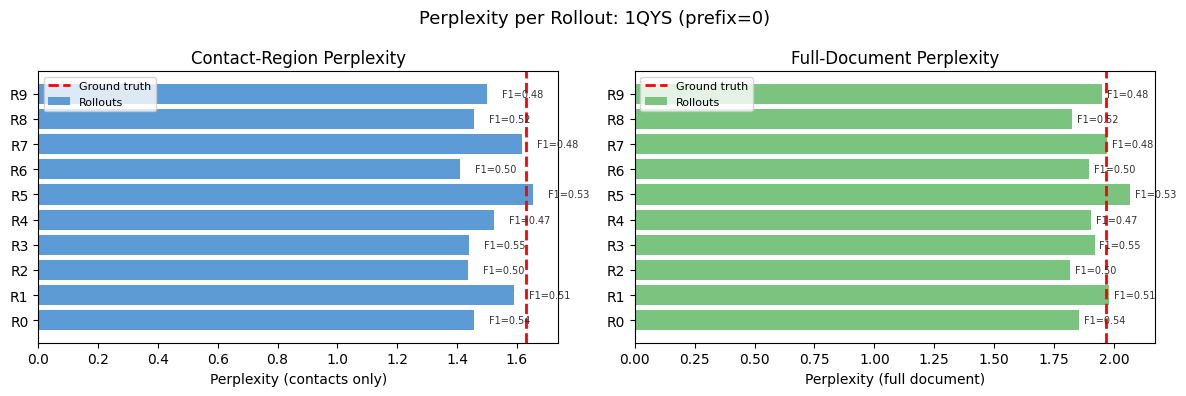

In [9]:
# Plot 1: Perplexity distribution with ground truth reference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contact-only perplexity
ax = axes[0]
ax.barh(range(N_ROLLOUTS), df["ppl_contacts"], color="#5C9BD5", label="Rollouts")
ax.axvline(gt_ppl_contacts, color="red", linewidth=2, linestyle="--", label="Ground truth")
ax.set_yticks(range(N_ROLLOUTS))
ax.set_yticklabels([f"R{r}" for r in range(N_ROLLOUTS)])
ax.set_xlabel("Perplexity (contacts only)")
ax.set_title("Contact-Region Perplexity")
ax.legend(fontsize=8)
# Annotate with F1
for i, row in df.iterrows():
    ax.text(row["ppl_contacts"] + 0.05, i, f"F1={row['f1']:.2f}",
            va="center", fontsize=7, color="#333")

# Full-doc perplexity
ax = axes[1]
ax.barh(range(N_ROLLOUTS), df["ppl_full"], color="#7BC47F", label="Rollouts")
ax.axvline(gt_ppl_full, color="red", linewidth=2, linestyle="--", label="Ground truth")
ax.set_yticks(range(N_ROLLOUTS))
ax.set_yticklabels([f"R{r}" for r in range(N_ROLLOUTS)])
ax.set_xlabel("Perplexity (full document)")
ax.set_title("Full-Document Perplexity")
ax.legend(fontsize=8)
for i, row in df.iterrows():
    ax.text(row["ppl_full"] + 0.02, i, f"F1={row['f1']:.2f}",
            va="center", fontsize=7, color="#333")

fig.suptitle(f"Perplexity per Rollout: {PDB_ID} (prefix=0)", fontsize=13)
plt.tight_layout()
plt.show()

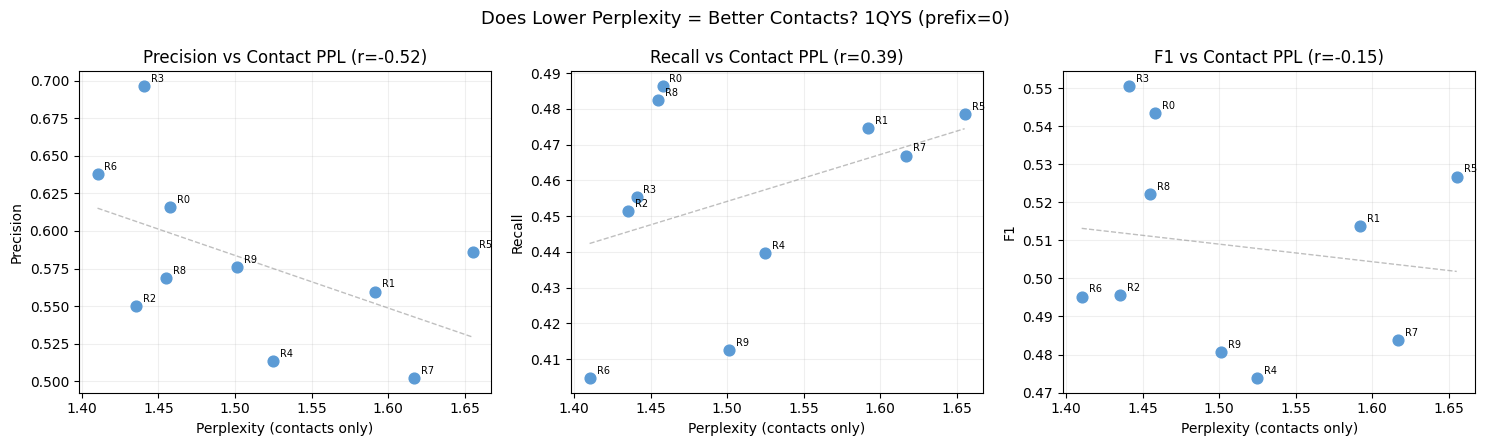

In [10]:
# Plot 2: Perplexity vs accuracy scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, metric_label in zip(axes, ["precision", "recall", "f1"],
                                     ["Precision", "Recall", "F1"]):
    ax.scatter(df["ppl_contacts"], df[metric], s=60, color="#5C9BD5", zorder=3,
              label="Rollouts")

    # Label each point with rollout number
    for _, row in df.iterrows():
        ax.annotate(f"R{int(row['rollout'])}",
                    (row["ppl_contacts"], row[metric]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)

    # Correlation
    if len(df) > 2:
        corr = df["ppl_contacts"].corr(df[metric])
        ax.set_title(f"{metric_label} vs Contact PPL (r={corr:.2f})")
    else:
        ax.set_title(f"{metric_label} vs Contact PPL")

    ax.set_xlabel("Perplexity (contacts only)")
    ax.set_ylabel(metric_label)
    ax.grid(True, alpha=0.2)

    # Fit line if enough points
    if len(df) > 2:
        z = np.polyfit(df["ppl_contacts"], df[metric], 1)
        p = np.poly1d(z)
        x_range = np.linspace(df["ppl_contacts"].min(), df["ppl_contacts"].max(), 50)
        ax.plot(x_range, p(x_range), "--", color="grey", alpha=0.5, linewidth=1)

fig.suptitle(f"Does Lower Perplexity = Better Contacts? {PDB_ID} (prefix=0)", fontsize=13)
plt.tight_layout()
plt.show()

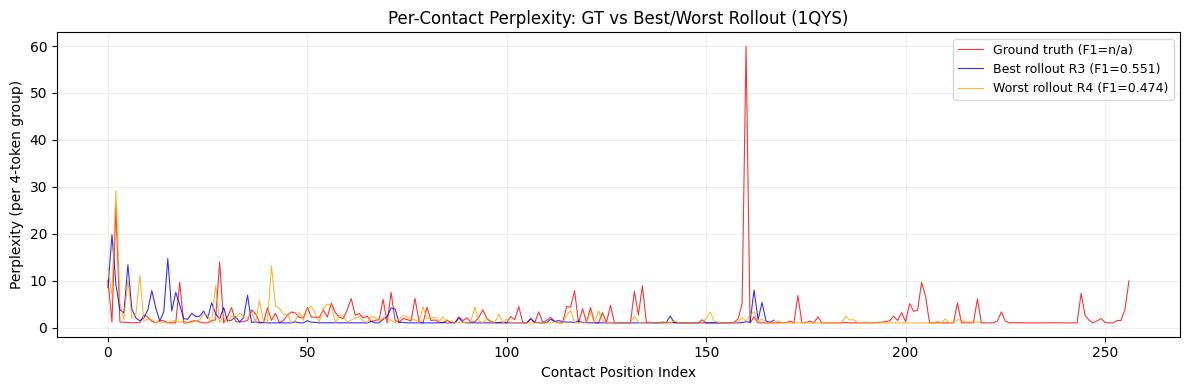

In [11]:
# Plot 3: Per-contact-position perplexity curves (GT vs best/worst rollout)
def compute_per_position_ppl(doc_text):
    """Compute per-contact-group (4-token) perplexity.

    Returns list of (position_index, perplexity) tuples.
    """
    encoding = tokenizer(doc_text, return_tensors="pt", truncation=True, max_length=8192)
    input_ids = encoding["input_ids"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids).logits

    shift_logits = logits[0, :-1]
    shift_labels = input_ids[0, 1:]
    per_token_loss = F.cross_entropy(shift_logits, shift_labels, reduction="none")

    ids = input_ids[0].tolist()
    bc_pos = None
    for idx, tid in enumerate(ids):
        if tid == begin_contacts_id:
            bc_pos = idx
            break
    if bc_pos is None:
        return []

    contact_start = bc_pos + 1
    # Each contact is 4 tokens; loss index is shifted by 1
    results = []
    pos = 0
    while True:
        loss_start = contact_start + pos * 4 - 1
        loss_end = loss_start + 4
        if loss_end > len(per_token_loss):
            break
        avg = per_token_loss[loss_start:loss_end].mean().item()
        results.append((pos, math.exp(avg)))
        pos += 1

    return results

# GT curve
gt_curve = compute_per_position_ppl(gt_doc)

# Best and worst rollout by F1
best_idx = df["f1"].idxmax()
worst_idx = df["f1"].idxmin()
best_doc = build_document(rollouts[best_idx][0])
worst_doc = build_document(rollouts[worst_idx][0])
best_curve = compute_per_position_ppl(best_doc)
worst_curve = compute_per_position_ppl(worst_doc)

fig, ax = plt.subplots(figsize=(12, 4))

if gt_curve:
    positions, ppls = zip(*gt_curve)
    ax.plot(positions, ppls, linewidth=0.8, color="red", label=f"Ground truth (F1=n/a)", alpha=0.8)
if best_curve:
    positions, ppls = zip(*best_curve)
    ax.plot(positions, ppls, linewidth=0.8, color="blue",
            label=f"Best rollout R{best_idx} (F1={df.loc[best_idx, 'f1']:.3f})", alpha=0.8)
if worst_curve:
    positions, ppls = zip(*worst_curve)
    ax.plot(positions, ppls, linewidth=0.8, color="orange",
            label=f"Worst rollout R{worst_idx} (F1={df.loc[worst_idx, 'f1']:.3f})", alpha=0.8)

ax.set_xlabel("Contact Position Index")
ax.set_ylabel("Perplexity (per 4-token group)")
ax.set_title(f"Per-Contact Perplexity: GT vs Best/Worst Rollout ({PDB_ID})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

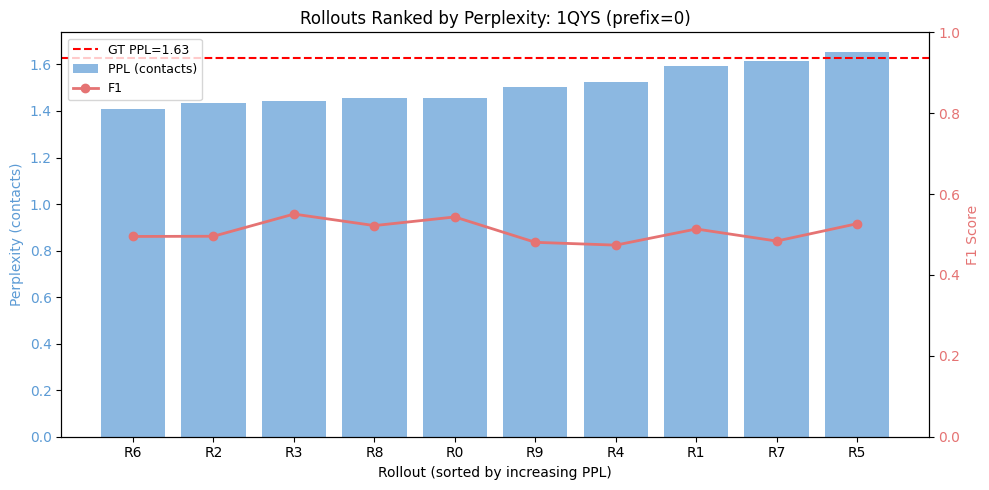


Correlation (PPL_contacts vs F1): r = -0.147
Correlation (PPL_full vs F1):     r = -0.033

Interpretation: Weak/no correlation - model perplexity may not reliably rank output quality


In [12]:
# Plot 4: Rank rollouts by perplexity, overlay accuracy
sorted_df = df.sort_values("ppl_contacts").reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(sorted_df))
color_ppl = "#5C9BD5"
color_f1 = "#E57373"

# Perplexity bars
bars = ax1.bar(x, sorted_df["ppl_contacts"], color=color_ppl, alpha=0.7, label="PPL (contacts)")
ax1.axhline(gt_ppl_contacts, color="red", linewidth=1.5, linestyle="--",
            label=f"GT PPL={gt_ppl_contacts:.2f}")
ax1.set_xlabel("Rollout (sorted by increasing PPL)")
ax1.set_ylabel("Perplexity (contacts)", color=color_ppl)
ax1.tick_params(axis="y", labelcolor=color_ppl)
ax1.set_xticks(x)
ax1.set_xticklabels([f"R{int(r)}" for r in sorted_df["rollout"]])

# F1 line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, sorted_df["f1"], "o-", color=color_f1, linewidth=2, markersize=6, label="F1")
ax2.set_ylabel("F1 Score", color=color_f1)
ax2.tick_params(axis="y", labelcolor=color_f1)
ax2.set_ylim(0, 1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title(f"Rollouts Ranked by Perplexity: {PDB_ID} (prefix=0)")
plt.tight_layout()
plt.show()

# Print correlation summary
corr_contacts = df["ppl_contacts"].corr(df["f1"])
corr_full = df["ppl_full"].corr(df["f1"])
print(f"\nCorrelation (PPL_contacts vs F1): r = {corr_contacts:.3f}")
print(f"Correlation (PPL_full vs F1):     r = {corr_full:.3f}")
print(f"\nInterpretation: {'Negative correlation suggests the model CAN score its outputs' if corr_contacts < -0.3 else 'Weak/no correlation - model perplexity may not reliably rank output quality'}")

In [13]:
# Visualize GT document tokens colored by per-token perplexity
from IPython.display import display, HTML
import matplotlib.colors as mcolors

def get_per_token_ppl(doc_text):
    """Return list of (token_string, perplexity) for each token.

    The first token has no perplexity (nothing to predict from), so it gets None.
    """
    encoding = tokenizer(doc_text, return_tensors="pt", truncation=True, max_length=8192)
    input_ids = encoding["input_ids"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids).logits

    shift_logits = logits[0, :-1]
    shift_labels = input_ids[0, 1:]
    per_token_loss = F.cross_entropy(shift_logits, shift_labels, reduction="none")

    ids = input_ids[0].tolist()
    tokens = [tokenizer.decode([tid]) for tid in ids]

    result = [(tokens[0], None)]  # first token has no loss
    for i, loss_val in enumerate(per_token_loss.tolist()):
        ppl = math.exp(loss_val)
        result.append((tokens[i + 1], ppl))
    return result

gt_token_ppls = get_per_token_ppl(gt_doc)

# Build HTML: color each token by perplexity using a diverging colormap
# Low PPL (easy to predict) = green, high PPL (surprising) = red
ppl_values = [p for _, p in gt_token_ppls if p is not None]
vmin, vmax = 1.0, np.percentile(ppl_values, 95)  # clip at 95th percentile for color range

cmap = plt.cm.RdYlGn_r  # red=high, green=low
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

html_parts = ['<div style="font-family: monospace; font-size: 11px; line-height: 1.8; '
              'background: white; padding: 10px; max-height: 600px; overflow-y: auto;">']
for i, (tok, ppl) in enumerate(gt_token_ppls):
    if ppl is None:
        color = "#cccccc"
        title = "first token (no PPL)"
    else:
        rgba = cmap(norm(min(ppl, vmax)))
        color = mcolors.to_hex(rgba)
        title = f"PPL={ppl:.1f}"

    # Newline before key structural tokens for readability
    if tok in ("<begin_sequence>", "<begin_contacts>", "<end_contacts>", "<end>"):
        html_parts.append("<br>")

    html_parts.append(
        f'<span style="background-color:{color}; padding:1px 3px; margin:1px; '
        f'border-radius:2px; display:inline-block;" title="{title}">{tok}</span>'
    )

    # Add line break every 20 contacts (80 tokens) in the contact region for readability
    if i > 0 and gt_token_ppls[i - 1][0] == "<begin_contacts>":
        contact_start_idx = i
    if hasattr(gt_token_ppls, '__len__') and i > 95 and (i - 95) % 80 == 0:
        html_parts.append("<br>")

html_parts.append("</div>")
html_parts.append(
    f'<div style="font-size: 11px; margin-top: 5px;">'
    f'Color scale: <span style="color:green">green=low PPL (easy)</span> to '
    f'<span style="color:red">red=high PPL (surprising)</span>. '
    f'Clipped at 95th percentile = {vmax:.1f}. '
    f'Hover over tokens to see exact PPL.</div>'
)

display(HTML("".join(html_parts)))

# Summary stats
contact_ppls = [p for t, p in gt_token_ppls if p is not None and t not in
                ("<deterministic-positives-only>", "<begin_sequence>", "<begin_contacts>",
                 "<end_contacts>", "<end>") and not t.startswith("<") or
                (p is not None and (t.startswith("<p") or t.startswith("<C") or t.startswith("<N")
                 or t.startswith("<O") or t.startswith("<S")))]
print(f"\nGT document: {len(gt_token_ppls)} tokens total")
print(f"PPL range: {min(ppl_values):.1f} - {max(ppl_values):.1f}")
print(f"PPL median: {np.median(ppl_values):.1f}, mean: {np.mean(ppl_values):.1f}")
print(f"Tokens with PPL > 100: {sum(1 for p in ppl_values if p > 100)} / {len(ppl_values)}")


GT document: 1125 tokens total
PPL range: 1.0 - 4197501.4
PPL median: 1.0, mean: 3773.3
Tokens with PPL > 100: 30 / 1124


In [14]:
# Print each GT contact with per-token perplexities
print("Ground truth document - per-token perplexity")
print("=" * 70)

# Print header/sequence tokens first
bc_idx = None
for i, (tok, ppl) in enumerate(gt_token_ppls):
    if tok == "<begin_contacts>":
        bc_idx = i
        break
    ppl_str = f"{ppl:8.1f}" if ppl is not None else "     n/a"
    print(f"  {ppl_str}  {tok}")

# Print contacts as groups of 4 tokens (pos1, pos2, atom1, atom2)
header = "Idx".rjust(4) + "  " + "Tokens".ljust(40) + "| PPL per token           | avg"
print(f"\n  {header}")
print("-" * 85)

contact_tokens = gt_token_ppls[bc_idx:]  # from <begin_contacts> onward
i = 0
group_ppls = []  # (contact_index, group_avg_ppl, tokens)
while i < len(contact_tokens):
    tok, ppl = contact_tokens[i]
    if tok in ("<begin_contacts>", "<end_contacts>", "<end>"):
        ppl_str = f"{ppl:8.1f}" if ppl is not None else "     n/a"
        print(f"  {ppl_str}  {tok}")
        i += 1
        continue
    # Read group of 4
    if i + 4 <= len(contact_tokens):
        group = contact_tokens[i:i+4]
        group_strs = []
        group_ppl_vals = []
        for t, p in group:
            group_strs.append(t)
            if p is not None:
                group_ppl_vals.append(p)
        avg_ppl = np.mean(group_ppl_vals) if group_ppl_vals else 0
        contact_idx = len(group_ppls)
        group_ppls.append((contact_idx, avg_ppl, group_strs))
        tok_ppls = " ".join(f"{p:5.1f}" if p is not None else "  n/a" for _, p in group)
        tok_strs = " ".join(f"{t:>6s}" for t, _ in group)
        marker = " <<<" if avg_ppl > 50 else (" <<" if avg_ppl > 20 else (
                  " <" if avg_ppl > 10 else ""))
        print(f"  [{contact_idx:3d}] {tok_strs}  | {tok_ppls} | {avg_ppl:6.1f}{marker}")
        i += 4
    else:
        # Remaining tokens
        for t, p in contact_tokens[i:]:
            ppl_str = f"{p:8.1f}" if p is not None else "     n/a"
            print(f"  {ppl_str}  {t}")
        break

# Print top-20 highest PPL contacts
print(f"\nTop 20 highest-perplexity contacts:")
print(f"  {'Idx':>4s}  {'Avg PPL':>8s}  Contact")
for idx, avg_ppl, toks in sorted(group_ppls, key=lambda x: -x[1])[:20]:
    print(f"  {idx:4d}  {avg_ppl:8.1f}  {' '.join(toks)}")


Ground truth document - per-token perplexity
       n/a  <deterministic-positives-only>
       1.0  <begin_sequence>
     334.5  <ASP>
      17.5  <ILE>
      31.1  <GLN>
      15.2  <VAL>
      29.2  <GLN>
      12.8  <VAL>
      20.1  <ASN>
      26.2  <ILE>
      12.6  <ASP>
      11.8  <ASP>
      19.5  <ASN>
      11.6  <GLY>
      12.6  <LYS>
      36.9  <ASN>
      17.7  <PHE>
      21.4  <ASP>
      25.4  <TYR>
      13.2  <THR>
      23.9  <TYR>
      10.1  <THR>
       8.8  <VAL>
       6.9  <THR>
      22.1  <THR>
      19.2  <GLU>
      14.0  <SER>
      17.5  <GLU>
      17.5  <LEU>
      25.4  <GLN>
      12.8  <LYS>
      11.8  <VAL>
       9.8  <LEU>
      10.4  <ASN>
       8.0  <GLU>
       6.0  <LEU>
      84.6  <MET>
      10.9  <ASP>
      27.5  <TYR>
      11.4  <ILE>
       8.2  <LYS>
       9.1  <LYS>
      15.4  <GLN>
      12.8  <GLY>
      26.2  <ALA>
       8.0  <LYS>
      51.3  <ARG>
       8.2  <VAL>
      31.6  <ARG>
       6.1  <ILE>
      13.2  <SER>
 